# Debug de la Simulación de Tráfico

Este notebook recorre cada etapa clave de la simulación:
1. Setup del módulo
2. Creación de la carretera (carriles)
3. Creación de los vehículos
4. Un paso de simulación
5. Simulación completa
6. Evaluación de métricas

## 1. Setup — cargar el módulo `TraficoSimulacion`

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # activa el entorno del proyecto
using TraficoSimulacion
using Statistics
using Plots
println("Módulo TraficoSimulacion cargado correctamente.")
println("Julia version: ", VERSION)

  Activating project at `~/Code/traffic-simulation`


Módulo TraficoSimulacion cargado correctamente.
Julia version: 1.10.4


## 2. Parámetros base

Los mismos que usa `configs/benchmark_rapido.yaml`.

In [3]:
# Geometría del vehículo
const a = 18/35       # ancho  [u]
const l = 9/7         # largo  [u]

# Carretera
const L     = 110.0    # longitud del circuito [u]
const d_0_1 = 0.5     # separación mínima carril 1
const d_0_2 = 0.5     # separación mínima carril 2

# Física
const α      = 0.8
const μ      = 0.8
const g      = 2.803
const T_reac = 1.0
const acel   = 1.0
const colchon = 0.21
const v_max  = 4.0
const v_min  = 0.001

# Comportamiento y temporización
const egoismo = 0.8
const δt      = 0.1
const error_tol = 1e-2
const err_dir   = 1e-6

# Número de vehículos
const n = 45          # carril 1
const m = 45          # carril 2

45

## 3. Creación de la carretera (carriles)

`carriles(A, N)` crea N carriles de ancho A. Cada `Carril` tiene:
- `ancho_carril` — ancho en x
- `inicio_fin` — intervalo `[x_min, x_max]` del carril
- `indice_carril`

Carriles creados (2):
  Carril 1: ancho=1,  x ∈ [0.0, 1.0]
  Carril 2: ancho=1,  x ∈ [1.0, 2.0]


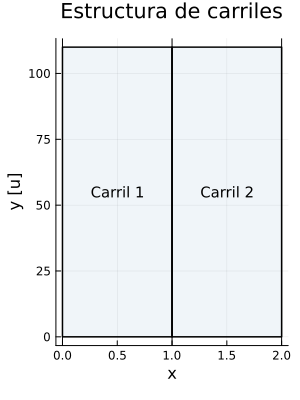

In [4]:
carriless = carriles(1, 2)
println("Carriles creados ($(length(carriless))):")
for c in carriless
    println("  Carril $(c.indice_carril): ancho=$(c.ancho_carril),  x ∈ $(c.inicio_fin)")
end
# Visualización esquemática
fig_carriles = plot(legend=false, title="Estructura de carriles",
                   xlabel="x", ylabel="y [u]", size=(300, 400))
for c in carriless
    x0, x1 = c.inicio_fin
    plot!(fig_carriles, [x0, x1, x1, x0, x0], [0, 0, L, L, 0],
          fill=true, fillalpha=0.08, color=:steelblue, lw=1.5, linecolor=:black)
    annotate!(fig_carriles, (x0+x1)/2, L/2, text("Carril $(c.indice_carril)", 10, :center))
end
vline!(fig_carriles, [0, 1, 2], color=:black, lw=1)
fig_carriles

## 4. Creación de los vehículos

`carros_dos_carriles(a, l, L, Δx₁, Δx₂, n, m)` crea `n` autos en el carril 1 y `m` en el carril 2.

90 vehículos creados.
  Carril 1: índices 1–45
  Carril 2: índices 46–90

Primeros 4 vehículos:
  Auto 1: pos=[0.5, 0.64]  vel=[0.0, 0.0]  dir=[0.0, 1.0]
  Auto 2: pos=[0.5, 2.43]  vel=[0.0, 0.0]  dir=[0.0, 1.0]
  Auto 3: pos=[0.5, 4.21]  vel=[0.0, 0.0]  dir=[0.0, 1.0]
  Auto 4: pos=[0.5, 6.0]  vel=[0.0, 0.0]  dir=[0.0, 1.0]


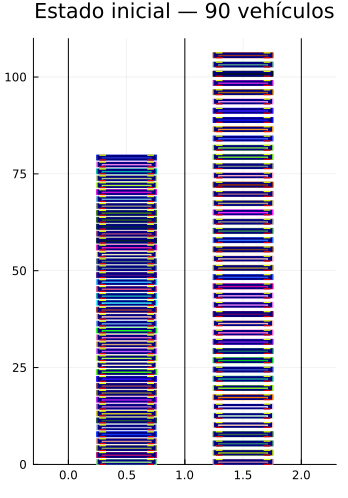

In [5]:
vehiculos = carros_dos_carriles(a, l, L, d_0_1, d_0_2 + 0.6, n, m; xs=1/2)

println("$(length(vehiculos)) vehículos creados.")
println("  Carril 1: índices 1–$n")
println("  Carril 2: índices $(n+1)–$(n+m)")
println()
println("Primeros 4 vehículos:")
for v in vehiculos[1:4]
    println("  Auto $(v.indice): pos=$(round.(v.posicion, digits=2))  ",
            "vel=$(round.(v.velocidad, digits=3))  ",
            "dir=$(round.(v.direccion, digits=3))")
end

# Visualizar estado inicial
fig_init = plot(vehiculos; title="Estado inicial — $(n+m) vehículos",
                ylim=(0, L), xlim=(-0.3, 2.3), legend=false, size=(350, 500))
vline!(fig_init, [0, 1, 2], color=:black, lw=1, label="")
fig_init

### 4a. Clasificación de vehículos por carril y fantasmas

`carros_i_carriles` devuelve para cada auto qué carriles ocupa.  
`listas_carros_fantasmas` proyecta cada auto en los dos carriles (necesario para calcular velocidades seguras con cambio de carril).

In [25]:
en_carril = carros_i_carriles(vehiculos, carriless)

println("Clasificación por carril (primeros 6):")
for i in 1:6
    println("  Auto $(en_carril[i][1]):  carril1=$(en_carril[i][2])  carril2=$(en_carril[i][3])")
end

fantasmas_1, fantasmas_2 = listas_carros_fantasmas(vehiculos)
println()
println("Fantasmas generados: $(length(fantasmas_1)) por carril")
println("  Fantasma del auto 1 → carril 1: pos=$(round.(fantasmas_1[1].posicion, digits=3))")
println("  Fantasma del auto 1 → carril 2: pos=$(round.(fantasmas_2[1].posicion, digits=3))")

Clasificación por carril (primeros 6):
  Auto 1:  carril1=true  carril2=false
  Auto 2:  carril1=true  carril2=false
  Auto 3:  carril1=true  carril2=false
  Auto 4:  carril1=true  carril2=false
  Auto 5:  carril1=true  carril2=false
  Auto 6:  carril1=true  carril2=false

Fantasmas generados: 90 por carril
  Fantasma del auto 1 → carril 1: pos=[0.5, 0.643]
  Fantasma del auto 1 → carril 2: pos=[1.5, 1.286]


## 5. Un paso de simulación

Ejecutamos un único paso de `avance_dos_carriles_con_giro_sin_anim` y comparamos posiciones y velocidades antes/después.

In [26]:
# Re-inicializar para empezar desde cero
vehiculos = carros_dos_carriles(a, l, L, d_0_1, d_0_2 + 0.6, n, m; xs=1/2)

# Snapshot antes
pos_antes = [copy(vehiculos[i].posicion) for i in eachindex(vehiculos)]
vel_antes = [copy(vehiculos[i].velocidad) for i in eachindex(vehiculos)]

# Preparar estado interno de giro
giro_nogiro    = comprobacion_giro(vehiculos)
θ_vec          = zeros(length(vehiculos))
en_carril      = carros_i_carriles(vehiculos, carriless)
carriles_orig  = carril_original(vehiculos, en_carril)

# Un solo paso
t_paso = @elapsed avance_dos_carriles_con_giro_sin_anim(
    vehiculos, θ_vec, carriless, carriles_orig, giro_nogiro,
    egoismo, δt, L, d_0_1, d_0_2, α, μ, g, T_reac, colchon, acel, v_max, v_min, n, m;
    error=error_tol, err=err_dir)

println("Paso ejecutado en $(round(t_paso*1000, digits=2)) ms")
println()
println("Δposición y Δvelocidad (autos 1–5):")
for i in 1:5
    Δy   = vehiculos[i].posicion[2] - pos_antes[i][2]
    v_nueva = vehiculos[i].velocidad[2]
    v_vieja = vel_antes[i][2]
    println("  Auto $i:  Δy=$(round(Δy, digits=5))  v: $(round(v_vieja,digits=4)) → $(round(v_nueva,digits=4))")
end

Paso ejecutado en 73.41 ms

Δposición y Δvelocidad (autos 1–5):
  Auto 1:  Δy=0.02543  v: 0.0 → 0.2543
  Auto 2:  Δy=0.02543  v: 0.0 → 0.2543
  Auto 3:  Δy=0.02543  v: 0.0 → 0.2543
  Auto 4:  Δy=0.02543  v: 0.0 → 0.2543
  Auto 5:  Δy=0.02543  v: 0.0 → 0.2543


### 5a. Verificación de colisiones tras el paso

In [27]:
# SAT fuerza bruta O(n²)
try
    haySuperposicionesSAT_error(vehiculos, 1)
    println("✓ Sin colisiones — SAT O(n²)")
catch e
    println("✗ Colisión detectada (bruto): ", e)
end

# SAT con grilla espacial O(n)
grilla = GrillaEspacial(Float64(L))
try
    haySuperposicionesSAT_error(vehiculos, 1; grilla=grilla)
    println("✓ Sin colisiones — SAT O(n) con grilla espacial")
catch e
    println("✗ Colisión detectada (grilla): ", e)
end

✓ Sin colisiones — SAT O(n²)
✓ Sin colisiones — SAT O(n) con grilla espacial


### 5b. Visualización después del paso

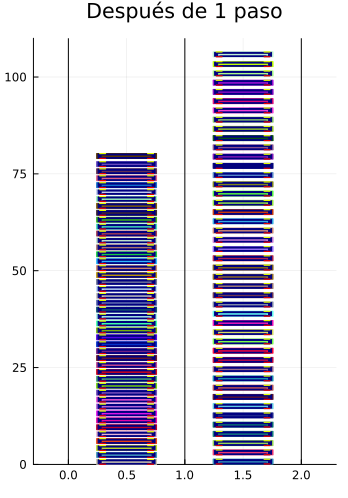

In [28]:
fig_paso = plot(vehiculos; title="Después de 1 paso",
                ylim=(0, L), xlim=(-0.3, 2.3), legend=false, size=(350, 500))
vline!(fig_paso, [0, 1, 2], color=:black, lw=1)
fig_paso

## 6. Simulación completa

`avance_dos_carril_valocidades_promedio` ejecuta todos los pasos y devuelve los arrays de tiempo `T` y velocidad promedio `V`.

Simulando 10000 pasos (1000.0 s simulados, 90 autos)...
  Completado en 762.52 s
  Velocidad inicial : 0.6254 u/paso
  Velocidad final   : 0.8253 u/paso
  Velocidad media   : 0.6715 u/paso


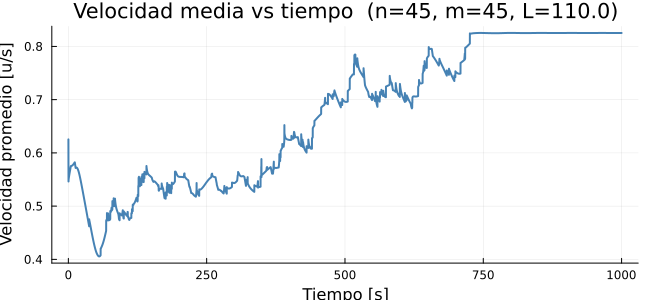

In [29]:
pasos = 10000

# Re-inicializar
vehiculos = carros_dos_carriles(a, l, L, d_0_1, d_0_2 + 0.6, n, m; xs=1/2)

println("Simulando $pasos pasos ($( pasos * δt ) s simulados, $(n+m) autos)...")
t_sim = @elapsed begin
    T, V = avance_dos_carril_valocidades_promedio(
        pasos, vehiculos, egoismo, δt, L, d_0_1, d_0_2,
        α, μ, g, T_reac, colchon, acel, v_max, v_min, n, m;
        error=error_tol, err=err_dir)
end
println("  Completado en $(round(t_sim, digits=2)) s")
println("  Velocidad inicial : $(round(V[1],   digits=4)) u/paso")
println("  Velocidad final   : $(round(V[end], digits=4)) u/paso")
println("  Velocidad media   : $(round(mean(V),digits=4)) u/paso")

plot(T, V;
     xlabel="Tiempo [s]", ylabel="Velocidad promedio [u/s]",
     title="Velocidad media vs tiempo  (n=$n, m=$m, L=$L)",
     legend=false, lw=2, color=:steelblue, size=(650, 300))

## 7. Evaluación de métricas

### 7a. Suavizado y tiempo crítico de estabilización

In [10]:
ventana = encontrar_ventana_optima(V)
V_suave = media_movil_simple(V, ventana)

t_crit, v_crit, derivada = encontrar_t_critico(T, V_suave)

println("Análisis de convergencia:")
if t_crit !== nothing
    println("  Tiempo crítico    : $(round(t_crit, digits=2)) s")
    println("  Velocidad estable : $(round(v_crit, digits=4)) u/s")
else
    println("  No se encontró estabilización clara")
end

p1 = plot(T, V; alpha=0.35, label="Cruda", lw=1, color=:steelblue)
plot!(p1, T, V_suave; label="Suavizada", lw=2, color=:red)
t_crit !== nothing && vline!(p1, [t_crit]; label="t_crit", color=:green, ls=:dash, lw=1.5)
xlabel!(p1, "Tiempo [s]"); ylabel!(p1, "V [u/s]"); title!(p1, "Convergencia")

p2 = plot(T, derivada; xlabel="Tiempo [s]", ylabel="dV/dt",
          title="Derivada numérica", legend=false, lw=1, color=:gray)
hline!(p2, [0.0]; color=:red, ls=:dash, lw=1)

plot(p1, p2; layout=(2,1), size=(700, 480))

Ventana recomendada: 15 puntos (5.0%)


BoundsError: BoundsError: attempt to access Tuple{Float64, Float64} at index [3]

### 7b. Doble suavizado desde el tiempo crítico

In [30]:
if t_crit !== nothing
    T_estable, V_estable_suave = doble_suavizado_desde_tcritico(T, t_crit, V_suave)
    v_promedio_estable = mean(V_estable_suave)
    println("Régimen estacionario:")
    println("  Desde t = $(round(t_crit, digits=2)) s hasta $(round(T_estable[end], digits=2)) s")
    println("  Velocidad media estable: $(round(v_promedio_estable, digits=4)) u/s")

    plot(T_estable, V_estable_suave;
         xlabel="Tiempo [s]", ylabel="V [u/s]",
         title="Régimen estacionario (doble suavizado)",
         legend=false, lw=2, color=:darkgreen, size=(650, 280))
else
    println("No se puede calcular doble suavizado sin t_crit.")
end

Ventana recomendada: 13 puntos (5.0%)


AssertionError: AssertionError: length(tiempo_nuevo) == length(velocidades_doble_suave)

### 7c. Métricas de tráfico: densidad, flujo, velocidad

─── Métricas de tráfico ──────────────────────
  Vehículos   : n=45 (carril 1)  m=45 (carril 2)  total=90
  Longitud    : L = 110.0 u
  Densidad ρ₁ : 0.4091 veh/u
  Densidad ρ₂ : 0.4091 veh/u
  Densidad ρ  : 0.4091 veh/u

  V inicial   : 0.6254 u/s
  V final     : 0.8253 u/s
  V estable   : 0.7856 u/s  (promedio segunda mitad)

  Flujo q     : 0.3214 veh/s  (= ρ × v_estable)


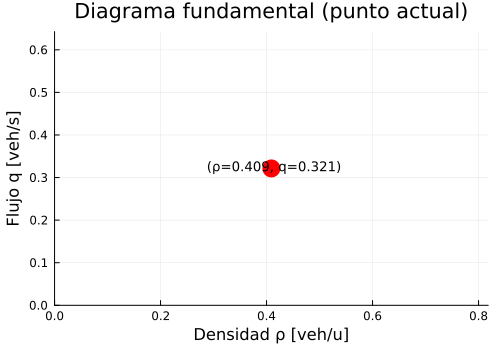

In [31]:
ρ1 = n / (1.0 * L)         # densidad carril 1 [veh/u]
ρ2 = m / (1.0 * L)         # densidad carril 2 [veh/u]
ρ  = (n + m) / (2.0 * L)   # densidad total

# Velocidad media en la segunda mitad de la simulación (régimen estable)
mitad = div(length(V), 2)
v_estable  = mean(V[mitad:end])
flujo      = ρ * v_estable

println("─── Métricas de tráfico ──────────────────────")
println("  Vehículos   : n=$n (carril 1)  m=$m (carril 2)  total=$(n+m)")
println("  Longitud    : L = $L u")
println("  Densidad ρ₁ : $(round(ρ1, digits=4)) veh/u")
println("  Densidad ρ₂ : $(round(ρ2, digits=4)) veh/u")
println("  Densidad ρ  : $(round(ρ,  digits=4)) veh/u")
println()
println("  V inicial   : $(round(V[1],        digits=4)) u/s")
println("  V final     : $(round(V[end],      digits=4)) u/s")
println("  V estable   : $(round(v_estable,   digits=4)) u/s  (promedio segunda mitad)")
println()
println("  Flujo q     : $(round(flujo, digits=4)) veh/s  (= ρ × v_estable)")

# Diagrama fundamental (un punto en el espacio ρ–q)
label_str = "(ρ=$(round(ρ,digits=3)), q=$(round(flujo,digits=3)))"
scatter([ρ], [flujo];
        ms=10, color=:red, markerstrokewidth=0,
        xlabel="Densidad ρ [veh/u]", ylabel="Flujo q [veh/s]",
        title="Diagrama fundamental (punto actual)",
        legend=false, size=(500, 350),
        xlim=(0, max(0.3, ρ*2)), ylim=(0, max(0.5, flujo*2)))
annotate!(ρ + 0.005, flujo + 0.005, text(label_str, 9))


### 7d. (Opcional) Guardar resultados en CSV

In [ ]:
# Descomentar para guardar:
# directorio_resultados = joinpath(@__DIR__, "..", "results", "debug_notebook")
# mkpath(directorio_resultados)
# guardarVelocidadesTiempos(T, V, ρ, egoismo; directorio=directorio_resultados)
println("(Guardado desactivado — descomentar para activar)")

## 8. Benchmark rápido del bucle de simulación

In [12]:
vehiculos_bench = carros_dos_carriles(a, l, L, d_0_1, d_0_2 + 0.6, n, m; xs=1/2)
carriless_b    = carriles(1, 2)
giro_b         = comprobacion_giro(vehiculos_bench)
θ_b            = zeros(length(vehiculos_bench))
enc_b          = carros_i_carriles(vehiculos_bench, carriless_b)
corig_b        = carril_original(vehiculos_bench, enc_b)

# Calentamiento JIT
avance_dos_carriles_con_giro_sin_anim(
    vehiculos_bench, θ_b, carriless_b, corig_b, giro_b,
    egoismo, δt, L, d_0_1, d_0_2, α, μ, g, T_reac, colchon, acel, v_max, v_min, n, m)

# Medición (10 pasos)
N_rep = 10
tiempos_bench = [begin
    @elapsed avance_dos_carriles_con_giro_sin_anim(
        vehiculos_bench, θ_b, carriless_b, corig_b, giro_b,
        egoismo, δt, L, d_0_1, d_0_2, α, μ, g, T_reac, colchon, acel, v_max, v_min, n, m)
end for _ in 1:N_rep]

t_ms = tiempos_bench .* 1000
println("Benchmark de un paso ($N_rep repeticiones, $(n+m) autos):")
println("  Media  : $(round(mean(t_ms), digits=2)) ms")
println("  Mín    : $(round(minimum(t_ms), digits=2)) ms")
println("  Máx    : $(round(maximum(t_ms), digits=2)) ms")
println("  Proyec.: ~$(round(mean(t_ms)*pasos/1000, digits=1)) s para $pasos pasos")

Benchmark de un paso (10 repeticiones, 35 autos):
  Media  : 11.23 ms
  Mín    : 8.98 ms
  Máx    : 20.79 ms
  Proyec.: ~3.4 s para 300 pasos
